## **Ejercicio 5. Proyecciones de la red**

---

## **Reconstrucción de la red bipartita del ejercicio 4**

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

SEMILLA = 123

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 170)

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DIR_PROCESSED = RAIZ / "data" / "processed"

comentarios = pd.read_csv(DIR_PROCESSED / "comentarios_limpio.csv", keep_default_na=False)
videos = pd.read_csv(DIR_PROCESSED / "videos_limpio.csv", keep_default_na=False)
videos["vistas"] = pd.to_numeric(videos.vistas)

titulo = videos.set_index("video_id").title.to_dict()
canal_por_video = videos.set_index("video_id").channel_name.to_dict()
categoria_por_video = videos.set_index("video_id").category.to_dict()
vistas_por_video = videos.set_index("video_id").vistas.to_dict()
nombre_autor = comentarios.set_index("author_channel_id").author_name.to_dict()
comentarios_por_video = comentarios.groupby("video_id").size()

red = nx.Graph()
red.add_nodes_from(comentarios.author_channel_id.unique(), tipo="autor", bipartite=0)
red.add_nodes_from(comentarios.video_id.unique(), tipo="video", bipartite=1)
for (autor, video), n in comentarios.groupby(["author_channel_id", "video_id"]).size().items():
    red.add_edge(autor, video, peso=int(n))

conjunto_autores = {n for n, d in red.nodes(data=True) if d["tipo"] == "autor"}
conjunto_videos = {n for n, d in red.nodes(data=True) if d["tipo"] == "video"}

AZUL, NARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GRIS, TINTA, TINTA_SUAVE, REJILLA = "#9a9994", "#0b0b0b", "#52514e", "#d8d7d2"

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlecolor": TINTA,
    "font.size": 9, "legend.frameon": False,
})

print(f"red bipartita: {red.number_of_nodes()} nodos, {red.number_of_edges()} aristas")

red bipartita: 351 nodos, 343 aristas


---

## **5.1. Proyección autor-autor**

In [13]:
proyeccion_autores = nx.bipartite.weighted_projected_graph(red, conjunto_autores)

pesos_autores = nx.get_edge_attributes(proyeccion_autores, "weight")
aislados_autores = [n for n in proyeccion_autores if proyeccion_autores.degree(n) == 0]

print("PROYECCION AUTOR-AUTOR")
print(f"  nodos                    : {proyeccion_autores.number_of_nodes()}")
print(f"  aristas                  : {proyeccion_autores.number_of_edges()}")
print(f"  peso de la arista        : numero de videos que los dos autores comentaron")
print(f"  peso maximo              : {max(pesos_autores.values())}")
print(f"  aristas con peso mayor a 1: {sum(1 for p in pesos_autores.values() if p > 1)}")
print(f"  autores aislados         : {len(aislados_autores)}")
print(f"  densidad                 : {nx.density(proyeccion_autores):.4f}")
print(f"  componentes conexas      : {nx.number_connected_components(proyeccion_autores)}")

PROYECCION AUTOR-AUTOR
  nodos                    : 332
  aristas                  : 10732
  peso de la arista        : numero de videos que los dos autores comentaron
  peso maximo              : 2
  aristas con peso mayor a 1: 2
  autores aislados         : 4
  densidad                 : 0.1953
  componentes conexas      : 10


---

## **5.2. Proyección video-video**

In [14]:
proyeccion_videos = nx.bipartite.weighted_projected_graph(red, conjunto_videos)

pesos_videos = nx.get_edge_attributes(proyeccion_videos, "weight")

print("PROYECCION VIDEO-VIDEO")
print(f"  nodos                    : {proyeccion_videos.number_of_nodes()}")
print(f"  aristas                  : {proyeccion_videos.number_of_edges()}")
print(f"  peso de la arista        : numero de autores que comentaron en ambos videos")
print(f"  peso maximo              : {max(pesos_videos.values())}")
print(f"  videos aislados          : {sum(1 for n in proyeccion_videos if proyeccion_videos.degree(n) == 0)}")
print(f"  densidad                 : {nx.density(proyeccion_videos):.4f}")
print(f"  componentes conexas      : {nx.number_connected_components(proyeccion_videos)}")

PROYECCION VIDEO-VIDEO
  nodos                    : 19
  aristas                  : 11
  peso de la arista        : numero de autores que comentaron en ambos videos
  peso maximo              : 2
  videos aislados          : 9
  densidad                 : 0.0643
  componentes conexas      : 10


In [15]:
resumen_videos = pd.DataFrame([
    {
        "grado": proyeccion_videos.degree(v),
        "peso_total": sum(d["weight"] for _, _, d in proyeccion_videos.edges(v, data=True)),
        "comentarios": int(comentarios_por_video[v]),
        "vistas": int(vistas_por_video[v]),
        "categoria": categoria_por_video[v],
        "canal": canal_por_video[v][:22],
        "titulo": titulo[v][:44],
    }
    for v in proyeccion_videos.nodes()
]).sort_values(["grado", "comentarios"], ascending=False).reset_index(drop=True)

print(f"Spearman entre grado y comentarios: {resumen_videos.grado.corr(resumen_videos.comentarios, method='spearman'):.3f}")
print(f"Spearman entre grado y vistas     : {resumen_videos.grado.corr(resumen_videos.vistas, method='spearman'):.3f}")
print(f"comentarios, mediana conectados   : {resumen_videos[resumen_videos.grado > 0].comentarios.median():.0f}")
print(f"comentarios, mediana aislados     : {resumen_videos[resumen_videos.grado == 0].comentarios.median():.0f}")
print()
resumen_videos

Spearman entre grado y comentarios: 0.678
Spearman entre grado y vistas     : 0.289
comentarios, mediana conectados   : 15
comentarios, mediana aislados     : 2



,grado,peso_total,comentarios,vistas,categoria,canal,titulo
0,4,5,161,11775,News & Politics,Quorum,Qué rico come tu diputado
1,4,5,12,717,News & Politics,Quorum,Internet: escoger el menos malo
2,3,4,50,10156,News & Politics,Quorum,La cooptación de Walter Mazariegos en la USA
3,2,2,45,11670,Entertainment,Gobierno de la Repúbli,Inician los trabajos de recuperación del Pue
4,2,2,25,3628,Entertainment,Gobierno de la Repúbli,Conferencia de Prensa del Gobierno de Guatem
5,2,3,16,1954,News & Politics,Quorum,Arroz con pollo a la MONOPOLIO
6,2,2,6,422,News & Politics,Quorum,Caminar en una ciudad hecha para carros
7,1,1,14,6692,News & Politics,Noti7,Capturan a presuntos delincuentes disfrazado
8,1,1,7,4616,News & Politics,TN23 Guatemala,Capturan a ladrón que había quedado grabado
9,1,1,7,5469,News & Politics,PrensaLibreOficial,Bloqueos en Guatemala este 31 de agosto por


---

## **5.3. Comparación de las dos proyecciones**

**Proyección autor-autor.** Esta proyección representa la co-participación entre personas, es decir,
conecta a dos autores cuando ambos comentaron el mismo video, y su peso indica en cuántos videos
coincidieron. Lo primero que salta es lo densa que se ve: 332 nodos con 10,732 aristas y una densidad
de 0.195, cifras que a primera vista sugerirían una comunidad muy conectada. No obstante, esa
densidad es engañosa, ya que proviene de un artificio de la proyección: cada video convierte a todos
sus comentaristas en un grupo completamente conectado entre sí, de tal forma que un solo video con
128 autores aporta por sí mismo más de ocho mil aristas sin que ninguna de esas personas se haya
dirigido a otra. La evidencia de que no hay convivencia real está en los pesos: de las 10,732
aristas, **solo 2 tienen peso mayor a 1**, o sea que casi ningún par de autores coincidió en más de
un video. Bajo esta idea, lo que la proyección muestra no es una red social sino la audiencia
simultánea de cada pieza de contenido, y los 4 autores aislados corresponden a los cuatro videos que
recibieron un único comentario.

**Proyección video-video.** Esta otra proyección representa el tráfico de audiencia entre contenidos,
ya que conecta dos videos cuando alguien comentó en los dos, y su peso indica cuántas personas
hicieron ese cruce. Aquí el panorama es el opuesto: 19 nodos con apenas 11 aristas y una densidad de
0.064, repartidos en 10 componentes. Los videos con más relaciones entre sí son *Internet: escoger el
menos malo* y *Qué rico come tu diputado*, ambos con grado 4, seguidos de *La cooptación de Walter
Mazariegos* con grado 3, y los tres son de Quorum, lo cual indica que el mayor tráfico de audiencia
ocurre dentro de un mismo canal y no entre canales distintos. Respecto a los 9 videos solitarios, en un
principio se pensó que serían contenido de poco atractivo, del tipo educativo o informativo, pero al
revisarlos los datos apuntan a otra explicación: 8 de los 9 son de la categoría News & Politics,
exactamente la misma de los videos mejor conectados, y ninguno pertenece a Education. Lo que sí explica la mayor parte del aislamiento es el tamaño, ya que los
videos conectados tienen una mediana de 15 comentarios frente a 2 en los aislados, y el grado
correlaciona con el número de comentarios en 0.678 mientras que con las visualizaciones apenas llega
a 0.289. Dicho esto, quedan dos excepciones que el tamaño no explica: *Plan 2032 Ciudad de Guatemala*
y *EE.UU. envía a mexicanos deportados* reunieron 25 comentarios cada uno y aun así quedaron
aislados, y considero que la razón es de audiencia y no de tema, pues pertenecen a la Municipalidad y
a un medio internacional, públicos que no se cruzan con el de Quorum.

---

## **5.4. Visualización de ambas proyecciones**

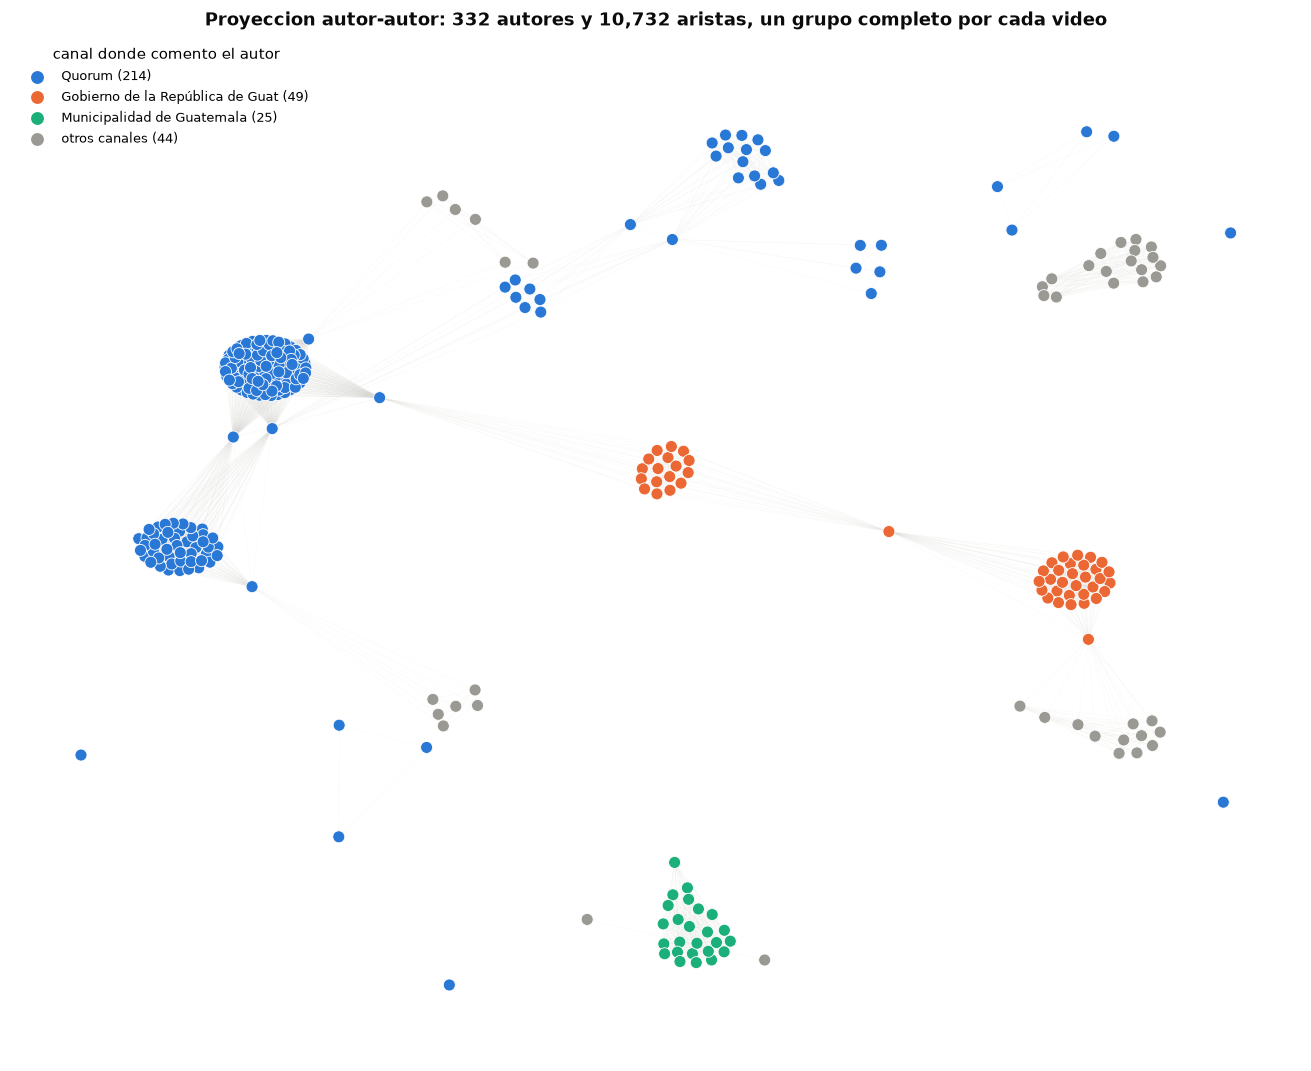

In [16]:
CANALES_DESTACADOS = ["Quorum", "Gobierno de la República de Guatemala", "Municipalidad de Guatemala"]
COLOR_CANAL = dict(zip(CANALES_DESTACADOS, [AZUL, NARANJA, AQUA]))


def canal_del_autor(autor):
    """Canal donde el autor dejo mas comentarios; los demas canales se agrupan."""
    canales = comentarios[comentarios.author_channel_id == autor].video_id.map(canal_por_video)
    principal = canales.value_counts().idxmax()
    return principal if principal in COLOR_CANAL else "otros canales"


canal_autor = {a: canal_del_autor(a) for a in proyeccion_autores.nodes()}
colores = [COLOR_CANAL.get(canal_autor[a], GRIS) for a in proyeccion_autores.nodes()]

posicion_autores = nx.spring_layout(proyeccion_autores, seed=SEMILLA, k=0.9, iterations=250)

fig, ax = plt.subplots(figsize=(11, 9))
nx.draw_networkx_edges(proyeccion_autores, posicion_autores, ax=ax,
                       edge_color=REJILLA, width=0.2, alpha=0.22)
nx.draw_networkx_nodes(proyeccion_autores, posicion_autores, ax=ax,
                       node_color=colores, node_size=52, linewidths=0.5, edgecolors="white")

for nombre, color in list(COLOR_CANAL.items()) + [("otros canales", GRIS)]:
    cuantos = sum(1 for a in canal_autor.values() if a == nombre)
    ax.scatter([], [], c=color, s=45, label=f"{nombre[:32]} ({cuantos})")
ax.legend(loc="upper left", fontsize=8, title="canal donde comento el autor")
ax.margins(0.06)
ax.set_title("Proyeccion autor-autor: 332 autores y 10,732 aristas, "
             "un grupo completo por cada video")
ax.axis("off")
plt.tight_layout()
plt.show()

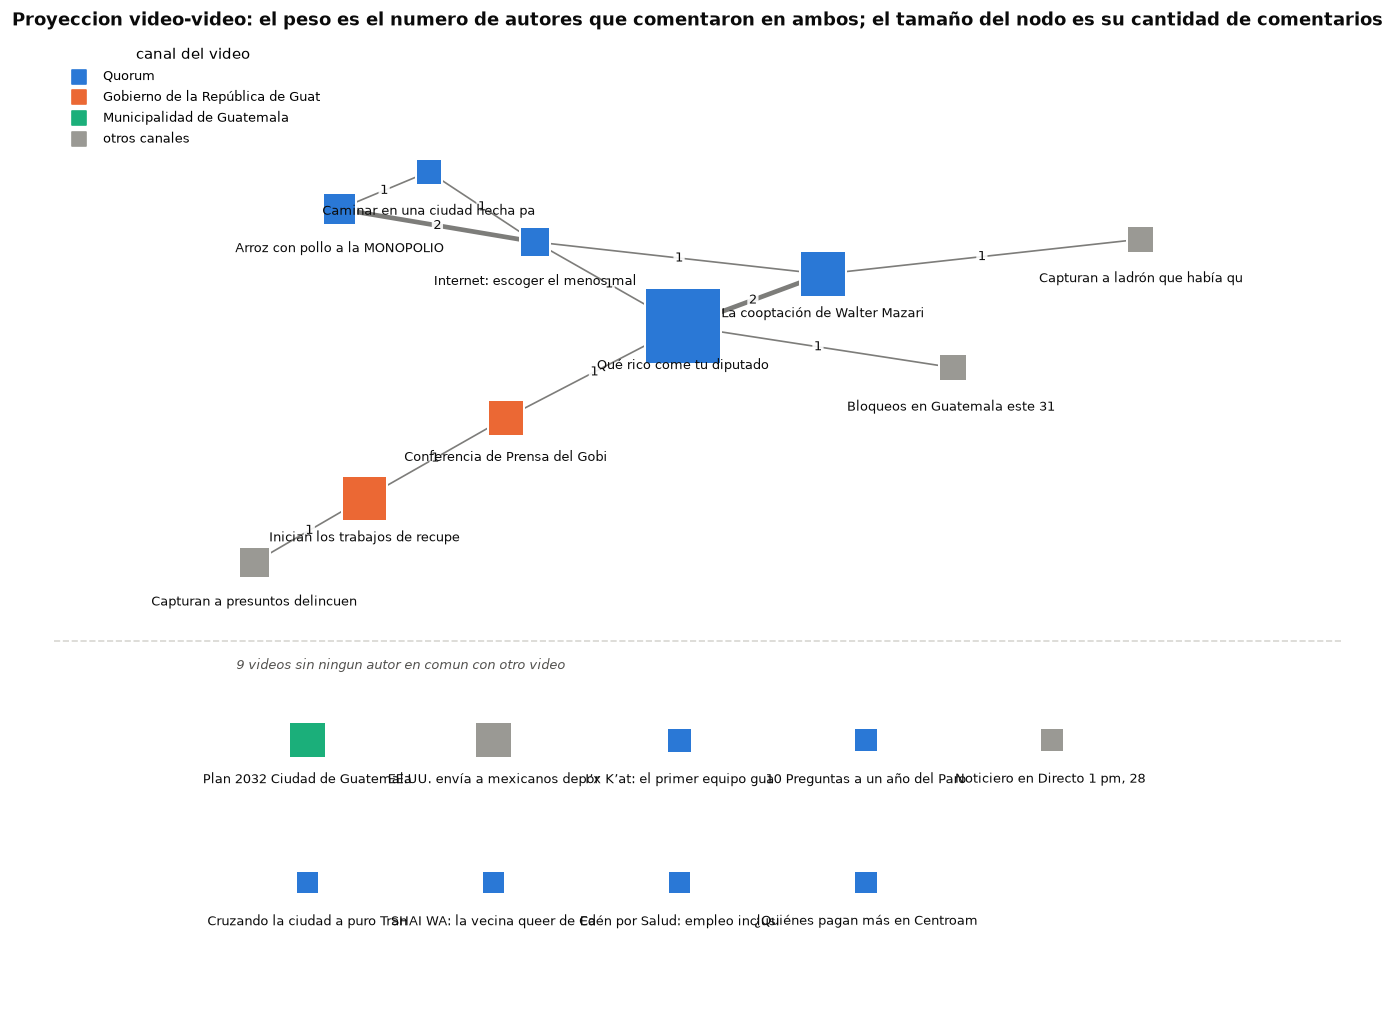

In [17]:
# El componente conectado se distribuye arriba y los aislados en filas abajo, para que
# el layout no comprima el nucleo al empujar lejos a los nodos sin aristas.
conectados_v = [v for v in proyeccion_videos if proyeccion_videos.degree(v) > 0]
aislados_v = [v for v in proyeccion_videos if proyeccion_videos.degree(v) == 0]

posicion_videos = nx.spring_layout(proyeccion_videos.subgraph(conectados_v),
                                   seed=SEMILLA, k=1.5, iterations=400)
xs = [x for x, _ in posicion_videos.values()]
ys = [y for _, y in posicion_videos.values()]
ancho, alto = max(xs) - min(xs), max(ys) - min(ys)
posicion_videos = {
    v: ((x - min(xs)) / ancho, 0.45 + 0.55 * (y - min(ys)) / alto)
    for v, (x, y) in posicion_videos.items()
}
for i, v in enumerate(sorted(aislados_v, key=lambda x: -comentarios_por_video[x])):
    posicion_videos[v] = (0.06 + 0.21 * (i % 5), 0.20 - 0.20 * (i // 5))

tamanos = [180 + 12 * comentarios_por_video[v] for v in proyeccion_videos.nodes()]
colores_video = [COLOR_CANAL.get(canal_por_video[v], GRIS) for v in proyeccion_videos.nodes()]

fig, ax = plt.subplots(figsize=(11, 8.5))
nx.draw_networkx_edges(proyeccion_videos, posicion_videos, ax=ax, edge_color=TINTA_SUAVE,
                       width=[1.0 + 1.8 * (p - 1) for p in pesos_videos.values()], alpha=0.75)
nx.draw_networkx_nodes(proyeccion_videos, posicion_videos, ax=ax, node_color=colores_video,
                       node_shape="s", node_size=tamanos, linewidths=1.2, edgecolors="white")
nx.draw_networkx_labels(proyeccion_videos,
                        {n: (x, y - 0.055) for n, (x, y) in posicion_videos.items()},
                        ax=ax, labels={v: titulo[v][:30] for v in proyeccion_videos.nodes()},
                        font_size=7.5, font_color=TINTA)
nx.draw_networkx_edge_labels(proyeccion_videos, posicion_videos, ax=ax, edge_labels=pesos_videos,
                             font_size=8, font_color=TINTA, rotate=False,
                             bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.9))

for nombre, color in list(COLOR_CANAL.items()) + [("otros canales", GRIS)]:
    ax.scatter([], [], c=color, marker="s", s=70, label=nombre[:32])
ax.legend(loc="upper left", fontsize=8, title="canal del video")
ax.axhline(0.34, color=REJILLA, linewidth=1, linestyle="--")
ax.text(-0.02, 0.30, f"{len(aislados_v)} videos sin ningun autor en comun con otro video",
        fontsize=8, color=TINTA_SUAVE, style="italic")
ax.margins(0.16)
ax.set_title("Proyeccion video-video: el peso es el numero de autores que comentaron en ambos; "
             "el tamaño del nodo es su cantidad de comentarios")
ax.axis("off")
plt.tight_layout()
plt.show()